In [1]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / "visdrone_yolo"

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_LABELS = DATASET_ROOT / "train" / "labels"

VAL_IMAGES = DATASET_ROOT / "val" / "images"
VAL_LABELS = DATASET_ROOT / "val" / "labels"

In [2]:
train_images = list(TRAIN_IMAGES.glob("*.jpg"))
train_labels = list(TRAIN_LABELS.glob("*.txt"))

val_images = list(VAL_IMAGES.glob("*.jpg"))
val_labels = list(VAL_LABELS.glob("*.txt"))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

Train images: 6471
Train labels: 6471
Val images: 548
Val labels: 548


In [3]:
image_name = "0000002_00005_d_0000014"

label_path = TRAIN_LABELS / f"{image_name}.txt"

with open(label_path, "r") as file:
    contents = file.read()

print(contents)

3 0.776042 0.902778 0.077083 0.061111
3 0.697396 0.829630 0.063542 0.085185
3 0.652083 0.786111 0.066667 0.094444
3 0.617188 0.757407 0.063542 0.070370
3 0.596354 0.719444 0.067708 0.061111
3 0.570833 0.649074 0.070833 0.064815
3 0.555208 0.615741 0.066667 0.057407
3 0.545312 0.579630 0.046875 0.051852
3 0.534375 0.550926 0.050000 0.050000
3 0.507292 0.512037 0.050000 0.053704
3 0.502604 0.487037 0.051042 0.040741
3 0.490104 0.466667 0.046875 0.037037
3 0.485938 0.443519 0.051042 0.035185
3 0.480729 0.415741 0.046875 0.038889
3 0.468750 0.402778 0.043750 0.035185
3 0.459896 0.387037 0.044792 0.037037
3 0.435937 0.364815 0.042708 0.033333
1 0.055208 0.748148 0.014583 0.048148
3 0.477083 0.842593 0.077083 0.081481
3 0.417708 0.672222 0.066667 0.062963
3 0.452083 0.801852 0.075000 0.085185
3 0.446875 0.761111 0.072917 0.066667
3 0.429688 0.709259 0.073958 0.070370
3 0.402083 0.606481 0.060417 0.057407
3 0.402083 0.572222 0.056250 0.040741
4 0.384896 0.550000 0.044792 0.051852
3 0.386458 0

In [4]:
invalid_lines = []

for label_path in train_labels:
    with open(label_path, "r") as file:
        for line_number, line in enumerate(file, start=1):

            values = line.strip().split()

            if len(values) != 5:
                invalid_lines.append(
                    (label_path.name, line_number, "wrong number of values")
                )
                continue

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])

            if not 0 <= class_id <= 10:
                invalid_lines.append(
                    (label_path.name, line_number, "invalid class ID")
                )

            if not 0 <= x_center <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "x_center outside [0,1]")
                )

            if not 0 <= y_center <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "y_center outside [0,1]")
                )

            if not 0 < width <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "width outside (0,1]")
                )

            if not 0 < height <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "height outside (0,1]")
                )

print("Invalid entries:", len(invalid_lines))

for item in invalid_lines[:20]:
    print(item)

Invalid entries: 0


In [5]:
invalid_lines = []

for label_path in train_labels:
    with open(label_path, "r") as file:
        for line_number, line in enumerate(file, start=1):

            values = line.strip().split()

            if len(values) != 5:
                invalid_lines.append(
                    (label_path.name, line_number, "wrong number of values")
                )
                continue

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])

            if not 0 <= class_id <= 10:
                invalid_lines.append(
                    (label_path.name, line_number, "invalid class ID")
                )

            if not 0 <= x_center <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "x_center outside [0,1]")
                )

            if not 0 <= y_center <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "y_center outside [0,1]")
                )

            if not 0 < width <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "width outside (0,1]")
                )

            if not 0 < height <= 1:
                invalid_lines.append(
                    (label_path.name, line_number, "height outside (0,1]")
                )

print("Invalid entries:", len(invalid_lines))

for item in invalid_lines[:20]:
    print(item)

Invalid entries: 0


In [10]:
CLASS_NAMES = [
    "pedestrian",
    "people",
    "bicycle",
    "car",
    "van",
    "truck",
    "tricycle",
    "awning-tricycle",
    "bus",
    "motor",
    "others"
]


def show_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_height, image_width = image.shape[:2]

    with open(label_path, "r") as file:
        for line in file:

            class_id, xc, yc, w, h = map(
                float,
                line.strip().split()
            )

            class_id = int(class_id)

            # Convert normalized YOLO coordinates
            # back to pixel coordinates
            xc *= image_width
            yc *= image_height
            w *= image_width
            h *= image_height

            x1 = int(xc - w / 2)
            y1 = int(yc - h / 2)
            x2 = int(xc + w / 2)
            y2 = int(yc + h / 2)

            # Draw bounding box
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            # Get class name
            label = CLASS_NAMES[class_id]

            # Draw class name
            cv2.putText(
                image,
                label,
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                1
            )

    plt.figure(figsize=(14, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

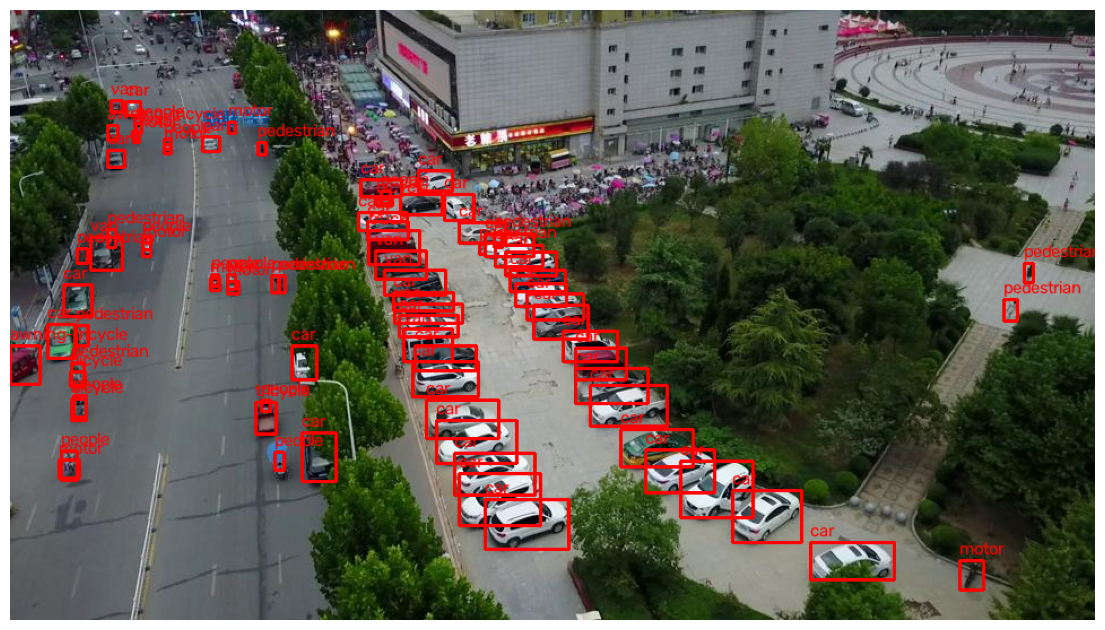

In [11]:
image_path = TRAIN_IMAGES / "0000002_00005_d_0000014.jpg"
label_path = TRAIN_LABELS / "0000002_00005_d_0000014.txt"

show_yolo_labels(image_path, label_path)

9999999_00199_d_0000082.jpg


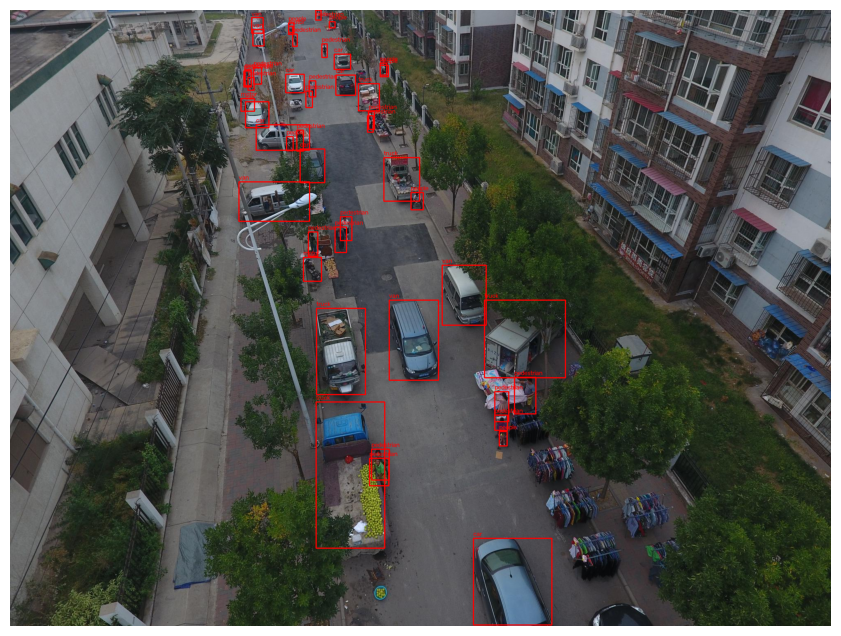

9999999_00125_d_0000047.jpg


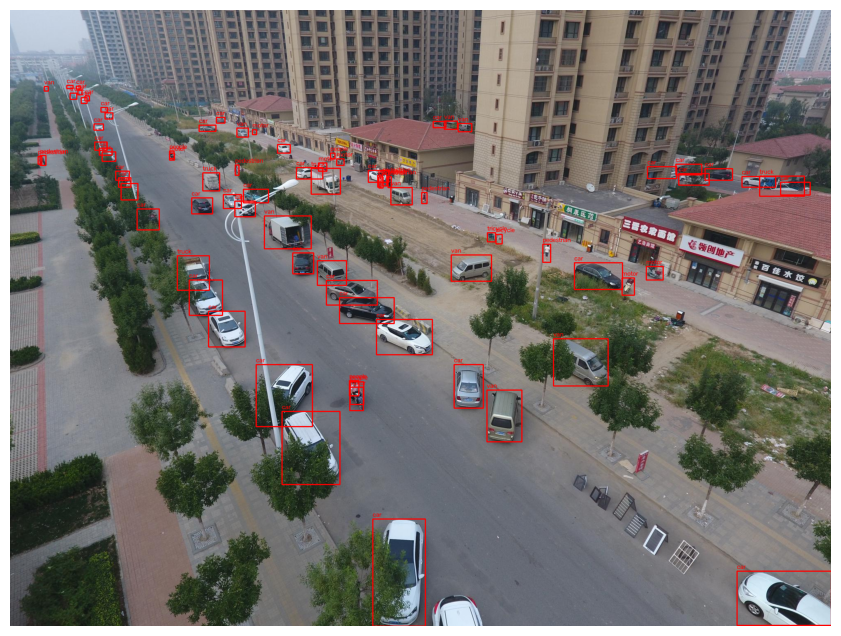

9999943_00000_d_0000032.jpg


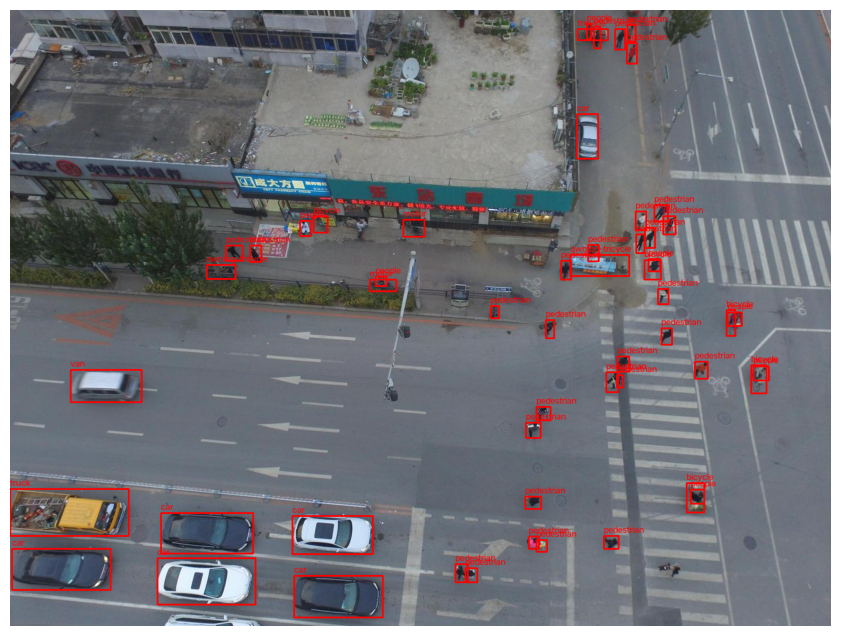

9999994_00000_d_0000027.jpg


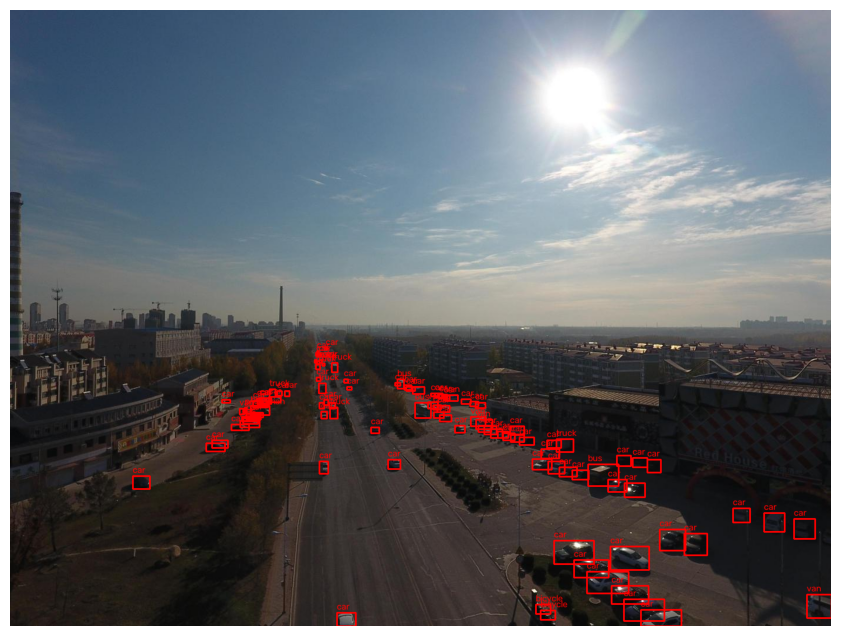

9999975_00000_d_0000012.jpg


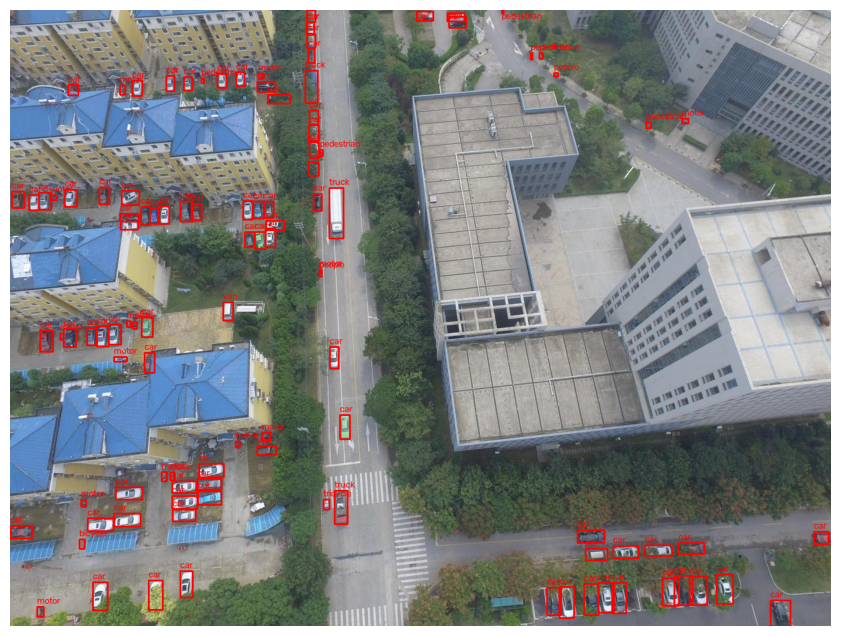

In [12]:
import random

random_images = random.sample(train_images, 5)

for image_path in random_images:
    label_path = TRAIN_LABELS / f"{image_path.stem}.txt"

    print(image_path.name)

    show_yolo_labels(
        image_path,
        label_path
    )

In [13]:
print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

print("Invalid entries:", len(invalid_lines))

Train images: 6471
Train labels: 6471
Val images: 548
Val labels: 548
Invalid entries: 0


In [14]:
empty_labels = []

for label_path in train_labels:
    if label_path.stat().st_size == 0:
        empty_labels.append(label_path.name)

print("Empty training labels:", len(empty_labels))
print(empty_labels[:20])

Empty training labels: 1
['9999974_00000_d_0000053.txt']


In [15]:
empty_val_labels = []

for label_path in val_labels:
    if label_path.stat().st_size == 0:
        empty_val_labels.append(label_path.name)

print("Empty validation labels:", len(empty_val_labels))
print(empty_val_labels[:20])

Empty validation labels: 0
[]
